"Radiomics-Based Differentiation: RCC vs. AML"

# 📊 The Clinical Challenge
---

### **Overview**
The primary objective is the accurate differentiation of renal masses to determine the appropriate surgical or medical pathway.

* **Classification is Critical:** Distinguishing between **Malignant (RCC)** and **Benign (AML)** is the cornerstone of renal oncology.
* **Renal Cell Carcinoma (RCC):** * Invasive and metastatic nature.
    * Requires aggressive intervention: Surgery, targeted therapy, or immunotherapy.
* **Angiomyolipoma (AML):** * A benign mesenchymal tumor.
    * Typically follows a "watch and wait" protocol; surgery is usually unnecessary.

> ### **The Dilemma**
> **Visual Overlap:** Fat-poor AMLs often mimic the enhancement patterns of RCC. Separation remains a major challenge for human vision alone, leading to high rates of unnecessary nephrectomies.

# ⏳  The Critical Timeline
---

### **Timing and Consequences**
In renal oncology, the interval between detection and diagnosis determines the patient's quality of life.

* **Delayed Action:** Failure to identify RCC promptly can lead to metastasis, resulting in life-threatening outcomes.
* **Unnecessary Intervention:** Misdiagnosing AML as RCC leads to redundant surgeries, loss of kidney function, and patient morbidity.
* **The Goal:** Achieving early and accurate **non-invasive diagnosis** to optimize surgical pathways and patient safety.

# 💡  Significance of the Study
---

### **Radiomics: Beyond Human Vision**
Medical imaging contains more data than the human eye can perceive. 

* **Uncovering Hidden Patterns:** Data mining implementations allow us to see features far beyond traditional human sense.
* **Hidden Biomarkers:** Feature extraction identifies "digital signatures" of tissue texture and heterogeneity.
* **Decision Support:** Providing critical assistance to medical decision-makers to save lives and reduce healthcare costs through precision medicine.

# 🔍 State of the Art vs. Gaps
---

### **Current Practice & Limitations**
* **Current Practice:** Physicians rely on subjective visual assessment of CT/MRI imaging.
* **The Gap:** **Fat-Poor AMLs** lack macroscopic fat, making them look identical to RCCs on standard imaging.
* **Human Limitation:** Subvisual texture patterns and complex spatial distributions are often missed by even expert radiologists.

> **Research Gap:** There is a need for a computational approach that quantifies these subvisual patterns to bridge the gap in diagnostic accuracy.

# ⚙️Our Methodology
---

### **The Radiomics Pipeline**
* **Computational Implementation:** Combining high-dimensional radiomics feature extraction with robust Machine Learning algorithms.
* **Unified Pipeline:** Creating a reproducible model capable of processing data across different medical institutions (UCSF & KiTS).

# 📂Data Characteristics
---

### **Datasets & Processing**
* **UCSF-RMAC:** A high-quality renal mass dataset used for feature discovery and clinical correlation.
* **KiTS23:** A standardized, multicenter dataset utilized for robust training and cross-institutional validation.
* **Ready-to-use Implementation:** Data utilized in its current high-fidelity state without manual image manipulation, ensuring the integrity of the original Hounsfield Units.

# ⚠️ Current Limitations
---

### **The "Lacking" Side of the Study**
* **Data Volumetrics:** Limited sample size for specific AML sub-types (Fat-poor vs. Fat-rich).
* **Classification Scope:** Current focus is on the broad binary classification of AML vs. RCC.
* **Future Goal:** Narrowing down specifically to **Fat-Poor AML** once more granular data is acquired to solve the most difficult clinical edge cases.

# ✅ Conclusion
---

### **Summary of Findings**
* **Hidden Messages:** Radiomics successfully extracts a "hidden message" from images for diagnostic assistance.
* **Performance:** ML performance  **:**  considerably good model even if it is counted as a "vanillia model".
* **Impact:** Accurate diagnosis equals avoiding unnecessary surgery for benign cases while acting in time for malignancies.

**Final takeaway: Data-driven diagnosis saves lives and preserves health.**

# 🧮 Texture Matrices
---

| Matrix | Mathematical Definition | Biological / Clinical Significance |
| :--- | :--- | :--- |
| **GLCM** | Frequency of specific gray-level pixel pairs. | **Local Homogeneity:** Identifies if tissue is uniform or "speckled." |
| **GLSZM** | Number of connected pixel "zones" of same intensity. | **Tissue Fragmentation:** Large zones = stable; Small zones = aggressive. |
| **GLRLM** | Length of consecutive pixels with same gray level. | **Directional Coarseness:** Captures vascular or fibrous "streaks." |
| **NGTDM** | Difference between a pixel and its neighbors. | **Visual Complexity:** Quantifies "chaos" invisible to the human eye. |

# 💎 Scaling Medical Intelligence
---

| Advantage | Computational Capability | Clinical Impact |
| :--- | :--- | :--- |
| **Uncover Hidden Data** | Mining "Digital Biomarkers" in pixels. | Detects patterns far beyond the human sense. |
| **Scale & Speed** | Scale-up and Scale-out implementation. | High-accuracy assistance provided in real-time. |
| **Data Reusability** | Automated analysis of historical archives. | Transforms "unused" idle images into research assets. |
| **Expert Support** | Mathematical & Objective processing. | Overcomes human fatigue and diagnostic subjectivity. |

# 🛠️ The Pre-processing Bottleneck
---

| Challenge | Technical Reality | Clinical Consequence |
| :--- | :--- | :--- |
| **Size Mismatch** | Images and Masks have non-overlapping sizes. | Pipeline failure; data becomes "idle" or unusable. |
| **Phase Alignment** | Different phases (Arterial vs. Venous) drift. | Spatial noise obscures the true "hidden message." |
| **The Requirement** | Features require exact 1:1 spatial overlap. | **Critical Need:** Advanced resampling and registration. |
| **The Solution** | Our Rigorous Image Processing Pipeline. | **Recovery:** Rescuing vital data for accurate extraction. |

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, recall_score, accuracy_score, precision_score, f1_score,classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, auc


In [3]:
dk = pd.read_json("kits23.json")

In [4]:
dk

,case_id,gender,vital_status,vital_days_after_surgery,bmi,comorbidities,age_at_nephrectomy,hospitalization,er_visit,readmission,...,tumor_histologic_subtype,tumor_necrosis,tumor_isup_grade,positive_resection_margins,sarcomatoid_features,rhabdoid_features,last_preop_egfr,first_postop_egfr,last_postop_egfr,aua_risk_score
0,case_00000,male,censored,1958,29.47,"{'myocardial_infarction': False, 'congestive_h...",49,2,0.0,0.0,...,clear_cell_rcc,0.0,3,0.0,0.0,0.0,"{'days_before_nephrectomy': 54, 'value': 77.0}","{'days_after_nephrectomy': 184, 'value': 76.0}","{'days_after_nephrectomy': 1958, 'value': 83.0}",intermediate_risk
1,case_00001,male,censored,1669,33.71,"{'myocardial_infarction': False, 'congestive_h...",50,6,1.0,0.0,...,papillary_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': 1, 'value': 67.0}","{'days_after_nephrectomy': 117, 'value': 58.0}","{'days_after_nephrectomy': 1623, 'value': 58.0}",low_risk
2,case_00002,male,censored,1694,28.13,"{'myocardial_infarction': False, 'congestive_h...",74,1,0.0,0.0,...,papillary_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': None, 'value': None}","{'days_after_nephrectomy': 76, 'value': 85.0}","{'days_after_nephrectomy': 1694, 'value': 84.0}",high_risk
3,case_00003,female,censored,114,38.69,"{'myocardial_infarction': False, 'congestive_h...",43,0,0.0,0.0,...,chromophobe_rcc,0.0,na,0.0,0.0,0.0,"{'days_before_nephrectomy': 61, 'value': 86.0}","{'days_after_nephrectomy': 114, 'value': 80.0}","{'days_after_nephrectomy': 114, 'value': 80.0}",low_risk
4,case_00004,male,censored,500,28.59,"{'myocardial_infarction': False, 'congestive_h...",72,2,0.0,0.0,...,clear_cell_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': None, 'value': None}","{'days_after_nephrectomy': 500, 'value': 54.0}","{'days_after_nephrectomy': 500, 'value': 54.0}",low_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,case_00584,female,censored,1974,30.79,"{'myocardial_infarction': False, 'congestive_h...",68,2,0.0,0.0,...,angiomyolipoma,0.0,na,1.0,0.0,0.0,"{'days_before_nephrectomy': 74, 'value': 55.0}","{'days_after_nephrectomy': 1, 'value': 83.0}","{'days_after_nephrectomy': 1969, 'value': 69.0}",benign
485,case_00585,male,censored,938,24.16,"{'myocardial_infarction': False, 'congestive_h...",28,1,1.0,0.0,...,chromophobe_rcc,0.0,na,0.0,0.0,0.0,"{'days_before_nephrectomy': 14, 'value': None}","{'days_after_nephrectomy': 938, 'value': None}","{'days_after_nephrectomy': 938, 'value': None}",low_risk
486,case_00586,male,dead,1717,26.72,"{'myocardial_infarction': False, 'congestive_h...",65,2,0.0,0.0,...,papillary_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': 1, 'value': 67.0}","{'days_after_nephrectomy': 1, 'value': 53.0}","{'days_after_nephrectomy': 1552, 'value': 59.0}",low_risk
487,case_00587,male,censored,2084,29.10,"{'myocardial_infarction': False, 'congestive_h...",72,2,0.0,0.0,...,clear_cell_papillary,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': 920, 'value': None}","{'days_after_nephrectomy': 104, 'value': 83.0}","{'days_after_nephrectomy': 1280, 'value': 85.0}",low_risk


In [5]:
dk["tumor_histologic_subtype"].value_counts()

tumor_histologic_subtype
clear_cell_rcc                 310
papillary_rcc                   45
chromophobe_rcc                 38
oncocytoma                      26
transitional_cell_carcinoma     17
clear_cell_papillary            12
other                           12
angiomyolipoma                   8
rcc_unclassified                 4
mest                             3
wilms_tumor                      3
spindle_cell_neoplasm            2
multilocular_cystic_rcc          2
cyst                             1
Name: count, dtype: int64

### KITS23 non-aml

In [6]:
dk0 = pd.read_csv("CSV_kits23/0.csv")

In [7]:
dk1 = pd.read_csv("CSV_kits23/1.csv")

In [8]:
dk2 = pd.read_csv("CSV_kits23/2.csv")

In [9]:
dk3 = pd.read_csv("CSV_kits23/3.csv")

In [10]:
dk4 = pd.read_csv("CSV_kits23/4.csv")

In [11]:
dk5 = pd.read_csv("CSV_kits23/5.csv")

In [12]:
dk6 = pd.read_csv("CSV_kits23/6.csv")

In [13]:
dfK = pd.concat([dk0,dk1,dk2,dk3,dk4,dk5,dk6], axis = 0, ignore_index= 1)

In [14]:
dfK.shape

(232, 130)

In [15]:
dfK["subset"] = "Original" 

In [16]:
dfK.shape

(232, 131)

In [17]:
dfK.columns.to_list()

['diagnostics_Versions_PyRadiomics',
 'diagnostics_Versions_Numpy',
 'diagnostics_Versions_SimpleITK',
 'diagnostics_Versions_PyWavelet',
 'diagnostics_Versions_Python',
 'diagnostics_Configuration_Settings',
 'diagnostics_Configuration_EnabledImageTypes',
 'diagnostics_Image-original_Hash',
 'diagnostics_Image-original_Dimensionality',
 'diagnostics_Image-original_Spacing',
 'diagnostics_Image-original_Size',
 'diagnostics_Image-original_Mean',
 'diagnostics_Image-original_Minimum',
 'diagnostics_Image-original_Maximum',
 'diagnostics_Mask-original_Hash',
 'diagnostics_Mask-original_Spacing',
 'diagnostics_Mask-original_Size',
 'diagnostics_Mask-original_BoundingBox',
 'diagnostics_Mask-original_VoxelNum',
 'diagnostics_Mask-original_VolumeNum',
 'diagnostics_Mask-original_CenterOfMassIndex',
 'diagnostics_Mask-original_CenterOfMass',
 'original_shape_Elongation',
 'original_shape_Flatness',
 'original_shape_LeastAxisLength',
 'original_shape_MajorAxisLength',
 'original_shape_Maximum

In [18]:
#Add data source column

dfK["data_source"] = "kits23"

In [19]:
dfK.shape

(232, 132)

In [20]:
aml_real = pd.read_csv("CSV_kits23_Test/Test_kits23.csv") 

### KITS23 aml

In [21]:
aml1 = pd.read_csv("CSV_aml_kits23/aml1.csv")

In [22]:
aml1["subset"] = "Original"

In [23]:
aml2 = pd.read_csv("CSV_aml_kits23/aml2.csv")

In [24]:
aml2["subset"] = "Original"

In [25]:
aml2

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,case_id,subset
0,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},816e3850ec5863f25777f90a33b82197d614f11e,3D,"(5.0, 0.7400000095367432, 0.7400000095367432)",...,6.508072,0.074720,136044.926688,42.294928,0.000051,647.449757,0.019277,0.043916,case_00569,Original
1,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},125748da193db54b9f9ec90bf79792cef0150750,3D,"(5.0, 0.677734375, 0.677734375)",...,6.456027,0.077945,207563.450133,15.027400,0.000040,3745.627492,0.004525,0.583931,case_00570,Original
2,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},0038a7165e10eaa7d302bef3109a611f5f8e2fa7,3D,"(2.5, 0.7714840173721313, 0.7714840173721313)",...,6.559260,0.063201,282050.814257,15.884438,0.000041,3410.382287,0.005707,0.759431,case_00584,Original


In [26]:
aml3 = pd.read_csv("CSV_aml_kits23/aml_kits23_dilated.csv")

In [27]:
aml3["subset"] = "Dilated"

In [28]:
aml4 = pd.read_csv("CSV_aml_kits23/aml_kits23_eroded.csv")

In [29]:
aml4["subset"] = "Eroded"

In [30]:
aml5 = pd.read_csv("CSV_aml_kits23/aml_kits23_flipped.csv")

In [31]:
aml5["subset"] = "Flipped"

In [32]:
df_aml = pd.concat([aml1,aml3,aml4,aml5], axis = 0, ignore_index= 1)

In [33]:
df_aml

,Unnamed: 0,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,...,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,case_id,subset
0,0.0,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},5108964cab9abc61848d21e00da4bca68ec1a5e1,3D,...,5.056181,0.064559,1.592319e+05,159.190262,0.000068,42.657989,0.029733,0.002978,case_00176,Original
1,1.0,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},bd65e96cb79fbd115dc14a59dc760eda3bdff89e,3D,...,5.885039,0.058884,2.825951e+05,129.529941,0.000043,72.055152,0.047372,0.003922,case_00043,Original
2,4.0,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},6355e0de3dffea048bf4c81c0a1fd4e4ed49766e,3D,...,5.955510,0.043111,4.711202e+05,115.728014,0.000044,79.960587,0.019996,0.005190,case_00137,Original
3,5.0,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},d051c00bec8b870775d416044be35bae51c3ecbf,3D,...,6.088195,0.075168,1.145055e+05,90.809250,0.000046,150.480645,0.075522,0.005810,case_00017,Original
4,7.0,3.1.1.dev111+g8ed579383,2.0.2,2.5.3,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},d7673a0b3e724b843b1d79468935f87f02d993fd,3D,...,5.770153,0.098116,4.616151e+04,57.421338,0.000075,182.630392,0.046336,0.009144,case_00205,Original
5,NaN,3.1.1.dev111+g8ed579383,2.0.2,2.5.4,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},c127e5b43c81f797668f0c21dc351502ca779301,3D,...,6.902947,0.038231,2.840649e+05,10.546232,0.000034,1318.281325,0.013291,0.098161,case_00470,Dilated
6,NaN,3.1.1.dev111+g8ed579383,2.0.2,2.5.4,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},d3063810732fe11fe800c16a14fe0f3516e075ea,3D,...,6.416563,0.067129,1.032658e+05,55.848549,0.000044,576.075610,0.049315,0.026857,case_00469,Dilated
7,NaN,3.1.1.dev111+g8ed579383,2.0.2,2.5.4,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},5108964cab9abc61848d21e00da4bca68ec1a5e1,3D,...,5.944062,0.055354,1.758934e+05,137.242812,0.000048,92.592093,0.071623,0.004417,case_00176,Dilated
8,NaN,3.1.1.dev111+g8ed579383,2.0.2,2.5.4,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},6355e0de3dffea048bf4c81c0a1fd4e4ed49766e,3D,...,6.200220,0.027621,6.534750e+05,115.230815,0.000042,91.499394,0.038428,0.006541,case_00137,Dilated
9,NaN,3.1.1.dev111+g8ed579383,2.0.2,2.5.4,1.8.0,3.12.12,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},bd65e96cb79fbd115dc14a59dc760eda3bdff89e,3D,...,6.414903,0.047829,2.962464e+05,93.402367,0.000039,126.720828,0.081935,0.006350,case_00043,Dilated


In [34]:
df_aml.shape

(29, 132)

In [35]:
df_aml.columns[-1]

'subset'

In [36]:
[i for i in df_aml.columns if i not in dfK.columns]

['Unnamed: 0']

In [37]:
df_aml = df_aml.drop(['Unnamed: 0'],axis=1)

In [38]:
df_aml.shape

(29, 131)

In [39]:
#Add dat source
df_aml["data_source"] = "kits23"

In [40]:
df_aml.shape

(29, 132)

### KITS23 META

In [41]:
dk_meta = pd.read_json("kits23.json")

In [42]:
dk_meta

,case_id,gender,vital_status,vital_days_after_surgery,bmi,comorbidities,age_at_nephrectomy,hospitalization,er_visit,readmission,...,tumor_histologic_subtype,tumor_necrosis,tumor_isup_grade,positive_resection_margins,sarcomatoid_features,rhabdoid_features,last_preop_egfr,first_postop_egfr,last_postop_egfr,aua_risk_score
0,case_00000,male,censored,1958,29.47,"{'myocardial_infarction': False, 'congestive_h...",49,2,0.0,0.0,...,clear_cell_rcc,0.0,3,0.0,0.0,0.0,"{'days_before_nephrectomy': 54, 'value': 77.0}","{'days_after_nephrectomy': 184, 'value': 76.0}","{'days_after_nephrectomy': 1958, 'value': 83.0}",intermediate_risk
1,case_00001,male,censored,1669,33.71,"{'myocardial_infarction': False, 'congestive_h...",50,6,1.0,0.0,...,papillary_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': 1, 'value': 67.0}","{'days_after_nephrectomy': 117, 'value': 58.0}","{'days_after_nephrectomy': 1623, 'value': 58.0}",low_risk
2,case_00002,male,censored,1694,28.13,"{'myocardial_infarction': False, 'congestive_h...",74,1,0.0,0.0,...,papillary_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': None, 'value': None}","{'days_after_nephrectomy': 76, 'value': 85.0}","{'days_after_nephrectomy': 1694, 'value': 84.0}",high_risk
3,case_00003,female,censored,114,38.69,"{'myocardial_infarction': False, 'congestive_h...",43,0,0.0,0.0,...,chromophobe_rcc,0.0,na,0.0,0.0,0.0,"{'days_before_nephrectomy': 61, 'value': 86.0}","{'days_after_nephrectomy': 114, 'value': 80.0}","{'days_after_nephrectomy': 114, 'value': 80.0}",low_risk
4,case_00004,male,censored,500,28.59,"{'myocardial_infarction': False, 'congestive_h...",72,2,0.0,0.0,...,clear_cell_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': None, 'value': None}","{'days_after_nephrectomy': 500, 'value': 54.0}","{'days_after_nephrectomy': 500, 'value': 54.0}",low_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,case_00584,female,censored,1974,30.79,"{'myocardial_infarction': False, 'congestive_h...",68,2,0.0,0.0,...,angiomyolipoma,0.0,na,1.0,0.0,0.0,"{'days_before_nephrectomy': 74, 'value': 55.0}","{'days_after_nephrectomy': 1, 'value': 83.0}","{'days_after_nephrectomy': 1969, 'value': 69.0}",benign
485,case_00585,male,censored,938,24.16,"{'myocardial_infarction': False, 'congestive_h...",28,1,1.0,0.0,...,chromophobe_rcc,0.0,na,0.0,0.0,0.0,"{'days_before_nephrectomy': 14, 'value': None}","{'days_after_nephrectomy': 938, 'value': None}","{'days_after_nephrectomy': 938, 'value': None}",low_risk
486,case_00586,male,dead,1717,26.72,"{'myocardial_infarction': False, 'congestive_h...",65,2,0.0,0.0,...,papillary_rcc,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': 1, 'value': 67.0}","{'days_after_nephrectomy': 1, 'value': 53.0}","{'days_after_nephrectomy': 1552, 'value': 59.0}",low_risk
487,case_00587,male,censored,2084,29.10,"{'myocardial_infarction': False, 'congestive_h...",72,2,0.0,0.0,...,clear_cell_papillary,0.0,2,0.0,0.0,0.0,"{'days_before_nephrectomy': 920, 'value': None}","{'days_after_nephrectomy': 104, 'value': 83.0}","{'days_after_nephrectomy': 1280, 'value': 85.0}",low_risk


### Add meta data into radiomics

In [43]:
#dfK = dfK.merge(dk_meta[["case_id","age_at_nephrectomy","gender","tumor_histologic_subtype","tumor_isup_grade","pathologic_size"]],on='case_id', how='inner')

In [44]:
dfK.shape

(232, 132)

In [45]:
df_aml.shape

(29, 132)

In [46]:
#df_aml = df_aml.merge(dk_meta[["case_id","age_at_nephrectomy","gender","tumor_histologic_subtype","tumor_isup_grade","pathologic_size"]],on='case_id', how='inner')

In [47]:
### UPDATE COLUMNS NAME to uniform columns with UCSF

In [48]:
# Define the mapping of KiTS23 columns to your Master Metadata names
rename_map = {
    "age_at_nephrectomy": "age",
    "gender": "gender",
    "tumor_histologic_subtype": "pathology_label",
    "tumor_isup_grade": "pathology_grade",
    "pathologic_size": "tumor_size"
}

# Perform the inner join and rename columns
dfK = dfK.merge(
    dk_meta[["case_id"] + list(rename_map.keys())], 
    on='case_id', 
    how='inner'
).rename(columns=rename_map)

# Quick check of the result
print(f"Joined KiTS dataframe shape: {dfK.shape}")
print(dfK[['case_id', 'pathology_label', 'tumor_size']].head())

Joined KiTS dataframe shape: (232, 137)
      case_id pathology_label  tumor_size
0  case_00126  clear_cell_rcc         4.5
1  case_00127  clear_cell_rcc         1.9
2  case_00128  clear_cell_rcc         4.2
3  case_00129  clear_cell_rcc         2.8
4  case_00130   papillary_rcc         5.7


In [49]:
dfK.shape

(232, 137)

In [50]:
# Define the mapping of KiTS23 columns to your Master Metadata names
rename_map = {
    "age_at_nephrectomy": "age",
    "gender": "gender",
    "tumor_histologic_subtype": "pathology_label",
    "tumor_isup_grade": "pathology_grade",
    "pathologic_size": "tumor_size"
}

# Perform the inner join and rename columns
df_aml = df_aml.merge(
    dk_meta[["case_id"] + list(rename_map.keys())], 
    on='case_id', 
    how='inner'
).rename(columns=rename_map)

# Quick check of the result
print(f"Joined KiTS dataframe shape: {df_aml.shape}")
print(df_aml[['case_id', 'pathology_label', 'tumor_size']].head())

Joined KiTS dataframe shape: (29, 137)
      case_id pathology_label  tumor_size
0  case_00176  angiomyolipoma         4.5
1  case_00043  angiomyolipoma         3.5
2  case_00137  angiomyolipoma         1.2
3  case_00017  angiomyolipoma         1.7
4  case_00205  angiomyolipoma         1.7


In [51]:
df_aml.shape

(29, 137)

In [52]:
len( [i for i in df_aml.columns if i in dfK.columns])

137

###  UCSF  --arterial  -- aml

In [297]:
dart1= pd.read_csv("CSV_art_new/art_new1.csv") #data source ekenmis

In [298]:
dart1["subset"] = "Original"

In [299]:
dart2= pd.read_csv("CSV_art_new/art_new2.csv")

In [300]:
dart2["subset"] = "Original"

In [301]:
dart3= pd.read_csv("CSV_art_new/art_3_resized.csv")

In [302]:
dart3["subset"] = "Original"

In [303]:
dart2.shape

(8, 131)

In [304]:
dart4= pd.read_csv("CSV_art_new/arterial_dilated.csv")

In [305]:
dart4["subset"] = "Dilated"

In [306]:
dart4.shape

(11, 131)

In [307]:
dart5= pd.read_csv("CSV_art_new/arterial_eroded.csv")

In [308]:
dart5["subset"] = "Eroded"

In [309]:
dart6= pd.read_csv("CSV_art_new/arterial_flipped.csv")

In [310]:
dart6["subset"] = "Flipped"

In [311]:
dfU = pd.concat([dart1,dart2,dart3,dart4,dart5,dart6], axis = 0, ignore_index= 1)

In [312]:
dfU.shape

(47, 131)

In [313]:
dfU["data_source"] = "ucsf-rmac"

In [314]:
dfU_meta = pd.read_csv("phase_reg_key.csv")

In [315]:
dfU_meta.columns

Index(['pid', 'noncon', 'arterial', 'delay', 'portven', 'mask',
       'ct_manufacturer', 'patient_age_years', 'patient_sex', 'pathology',
       'tumor_type', 'pathology_grade', 'tumor_laterality', 'tumor_size_cm',
       'tumor_biopsy_type'],
      dtype='object')

In [316]:
#LAZIM OLURSA META DATA

In [317]:
import pandas as pd

# 1. Clean the case_id
# Remove '.hdf5' so 'case_id' in your features matches 'pid' in the metadata file
dfU['case_id'] = dfU['case_id'].str.replace('.hdf5', '', regex=False)

# 2. Define the exact mapping to match KiTS23 standards
# This ensures clinical variables are identical in both dataframes
rename_map = {
    'patient_age_years': 'age',
    'patient_sex': 'gender',
    'tumor_type': 'pathology_label',
    'pathology_grade': 'pathology_grade',
    'tumor_size_cm': 'tumor_size'
}

# 3. Perform the Merge
# We only pull the 'pid' (for joining) and the specific keys from our rename_map
dfU = dfU.merge(
    dfU_meta[["pid"] + list(rename_map.keys())], 
    left_on='case_id', 
    right_on='pid', 
    how='inner'
).rename(columns=rename_map)

# 4. Final Cleanup
# Drop the redundant 'pid' and add the data source identifier
dfU.drop(columns=['pid'], inplace=True, errors='ignore')
dfU['data_source'] = 'UCSF-RMAC'

print("--- Metadata Alignment Complete ---")
print(f"Total UCSF cases: {len(dfU)}")
print(f"Standardized columns added: {list(rename_map.values())}")

--- Metadata Alignment Complete ---
Total UCSF cases: 47
Standardized columns added: ['age', 'gender', 'pathology_label', 'pathology_grade', 'tumor_size']


In [318]:
dfU.shape

(47, 137)

In [319]:
dfK["target"] = 0

In [320]:
df_aml["target"] = 1

In [321]:
dfkits = pd.concat([dfK,df_aml], axis = 0, ignore_index= 1)

In [322]:
dfU["target"] = 1

In [323]:
pd.set_option("display.max_columns",150)

In [324]:
dfU.head()

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,diagnostics_Image-original_Size,diagnostics_Image-original_Mean,diagnostics_Image-original_Minimum,diagnostics_Image-original_Maximum,diagnostics_Mask-original_Hash,diagnostics_Mask-original_Spacing,diagnostics_Mask-original_Size,diagnostics_Mask-original_BoundingBox,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,diagnostics_Mask-original_CenterOfMassIndex,diagnostics_Mask-original_CenterOfMass,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_Id,original_glcm_Idm,original_glcm_Idmn,original_glcm_Idn,original_glcm_Imc1,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointAverage,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm

In [325]:
dfU.shape

(47, 138)

In [326]:
dfkits.shape

(261, 138)

In [327]:
#Numeric columns
ls_numeric = dfK.loc[:,"original_shape_Elongation":"original_ngtdm_Strength"].columns.to_list()

In [328]:
len(ls_numeric)

107

In [329]:
ls_numeric.extend(["age","tumor_size"])

In [330]:
len(ls_numeric)

109

In [331]:
dfU['gender'].value_counts()

gender
F    39
M     8
Name: count, dtype: int64

In [332]:
dfkits['gender'].value_counts()

gender
male      153
female    108
Name: count, dtype: int64

In [232]:
x_list = []

In [233]:
x_list.extend(dfK.loc[:,"original_shape_Elongation":"original_ngtdm_Strength"].columns.to_list())

In [234]:
x_list.extend(["age","tumor_size"])

In [235]:
x_list.append("gender")

In [333]:
dfK.iloc[:,-6:]

,age,gender,pathology_label,pathology_grade,tumor_size,target
0,66,male,clear_cell_rcc,3,4.5,0
1,46,male,clear_cell_rcc,1,1.9,0
2,60,male,clear_cell_rcc,2,4.2,0
3,46,male,clear_cell_rcc,2,2.8,0
4,72,female,papillary_rcc,2,5.7,0
...,...,...,...,...,...,...
227,62,male,clear_cell_rcc,2,5.2,0
228,81,female,clear_cell_rcc,2,2.4,0
229,55,female,oncocytoma,na,9.5,0
230,53,male,clear_cell_rcc,2,3.3,0


In [237]:
patterns = "rcc|carcinoma"

In [334]:
dfK["pathology_label"]

0            clear_cell_rcc
1            clear_cell_rcc
2            clear_cell_rcc
3            clear_cell_rcc
4             papillary_rcc
               ...         
227          clear_cell_rcc
228          clear_cell_rcc
229              oncocytoma
230          clear_cell_rcc
231    clear_cell_papillary
Name: pathology_label, Length: 232, dtype: object

In [360]:
##carcinoma and rcc type
df_rcc1 = dfK[dfK["pathology_label"]=="clear_cell_rcc"].sample(25)
df_rcc2 = dfK[dfK["pathology_label"]=="papillary_rcc"].sample(20)
df_rcc3 = dfK[dfK["pathology_label"]=="chromophobe_rcc"].sample(19)
df_rcc4 = dfK[dfK["pathology_label"]=="transitional_cell_carcinoma"]
df_rcc5 = dfK[dfK["pathology_label"]=="multilocular_cystic_rcc"]


In [361]:
dfR = pd.concat([df_rcc1,df_rcc2, df_rcc3, df_rcc4, df_rcc5], axis = 0, ignore_index= 1)

In [362]:
dfR.drop(index=0,axis = 0,inplace=True)

In [363]:
dfR.shape

(70, 138)

In [364]:
dfR.isnull().sum().sum()

0

In [365]:
df = pd.concat([dfR,df_aml,dfU], axis = 0, ignore_index= 1)

In [366]:
df.drop("pathology_label",axis=1, inplace=True)

In [367]:
df.gender.value_counts()

gender
male      50
female    49
F         39
M          8
Name: count, dtype: int64

In [368]:
df.gender = df.gender.map({"female":0,"F":0,"male":1,"M":1})

In [369]:
df.gender.value_counts()

gender
0    88
1    58
Name: count, dtype: int64

In [370]:
X = df.drop("target",axis=1)

In [371]:
y = df["target"]

In [372]:
X = X.loc[:,ls_numeric]

In [373]:
y = df["target"]

In [374]:
pd.__version__

'2.2.2'

In [375]:
np.__version__

'1.26.4'

In [376]:
from sklearn.model_selection import train_test_split

In [389]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1,random_state=49)

In [390]:
from sklearn.preprocessing import StandardScaler

In [391]:
sc = StandardScaler()

In [392]:
sc_X_train = sc.fit_transform(X_train)

In [393]:
sc_X_test = sc.transform(X_test)

In [394]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

### SVM

In [395]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

In [396]:
svc.fit(sc_X_train,y_train)

SVC()

In [397]:
y_pred = svc.predict(sc_X_test)

In [398]:
y_pred

array([0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [399]:
eval_metric(svc, sc_X_train, y_train, sc_X_test, y_test)

Test_Set
[[4 1]
 [1 9]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.90      0.90      0.90        10

    accuracy                           0.87        15
   macro avg       0.85      0.85      0.85        15
weighted avg       0.87      0.87      0.87        15


Train_Set
[[65  0]
 [15 51]]
              precision    recall  f1-score   support

           0       0.81      1.00      0.90        65
           1       1.00      0.77      0.87        66

    accuracy                           0.89       131
   macro avg       0.91      0.89      0.88       131
weighted avg       0.91      0.89      0.88       131



In [400]:
review = df.iloc[X_test.index,:]

In [401]:
review['prediction']=y_pred

/tmp/ipykernel_15215/1888245410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review['prediction']=y_pred


In [402]:
df

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,diagnostics_Image-original_Size,diagnostics_Image-original_Mean,diagnostics_Image-original_Minimum,diagnostics_Image-original_Maximum,diagnostics_Mask-original_Hash,diagnostics_Mask-original_Spacing,diagnostics_Mask-original_Size,diagnostics_Mask-original_BoundingBox,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,diagnostics_Mask-original_CenterOfMassIndex,diagnostics_Mask-original_CenterOfMass,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_Id,original_glcm_Idm,original_glcm_Idmn,original_glcm_Idn,original_glcm_Imc1,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointAverage,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm

In [403]:
X_test

,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_Id,original_glcm_Idm,original_glcm_Idmn,original_glcm_Idn,original_glcm_Imc1,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointAverage,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,age,tumor_size
68,0.481535,0.198441,47.768167,240.717004,186.027122,183.487763,122.084869,187.102435,299795.351950,115.913694,0.370774,58424.040963,0.194880,300196.683742,31.000000,209.000000,4.505193e+09,3.361122,86.000000,3.132531,346.000000,53.293151,134.748081,148.000000,-127.000000,473.000000,36.727132,150.569498,-0.769515,6.805811e+09,0.116926,4514.128300,151.326999,1565.634922,-88.525309,22.009462,4.752038,0.644267,1.600130,2.329401,2.133435,0.514619,0.456932,0.9

In [404]:
review

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,diagnostics_Image-original_Size,diagnostics_Image-original_Mean,diagnostics_Image-original_Minimum,diagnostics_Image-original_Maximum,diagnostics_Mask-original_Hash,diagnostics_Mask-original_Spacing,diagnostics_Mask-original_Size,diagnostics_Mask-original_BoundingBox,diagnostics_Mask-original_VoxelNum,diagnostics_Mask-original_VolumeNum,diagnostics_Mask-original_CenterOfMassIndex,diagnostics_Mask-original_CenterOfMass,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_Id,original_glcm_Idm,original_glcm_Idmn,original_glcm_Idn,original_glcm_Imc1,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointAverage,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm

In [410]:
# Define the mapping of KiTS23 columns to your Master Metadata names
rename_map = {
    "age_at_nephrectomy": "age",
    "gender": "gender",
    "tumor_histologic_subtype": "pathology_label",
    "tumor_isup_grade": "pathology_grade",
    "pathologic_size": "tumor_size"
}

# Perform the inner join and rename columns
aml_real = aml_real.merge(
    dk_meta[["case_id"] + list(rename_map.keys())], 
    on='case_id', 
    how='inner'
).rename(columns=rename_map)

# Quick check of the result
print(f"Joined KiTS dataframe shape: {aml_real.shape}")
print(aml_real[['case_id', 'pathology_label', 'tumor_size']].head())

Joined KiTS dataframe shape: (94, 135)
      case_id  pathology_label  tumor_size
0  case_00580   clear_cell_rcc         2.5
1  case_00588   clear_cell_rcc         2.9
2  case_00585  chromophobe_rcc         1.9
3  case_00586    papillary_rcc         2.2
4  case_00582   clear_cell_rcc         2.1


In [411]:
aml_real.shape

(94, 135)

In [419]:
aml_real.isnull().sum()

diagnostics_Versions_PyRadiomics     0
diagnostics_Versions_Numpy           0
diagnostics_Versions_SimpleITK       0
diagnostics_Versions_PyWavelet       0
diagnostics_Versions_Python          0
                                    ..
age                                  0
gender                               0
pathology_label                      5
pathology_grade                      7
tumor_size                          15
Length: 135, dtype: int64

In [464]:
real = aml_real.loc[:,ls_numeric]

In [465]:
real = real.dropna()

In [466]:
X_train.shape

(131, 109)

In [467]:
real.shape

(79, 109)

In [417]:
real.

original_shape_Elongation                  0
original_shape_Flatness                    0
original_shape_LeastAxisLength             0
original_shape_MajorAxisLength             0
original_shape_Maximum2DDiameterColumn     0
                                          ..
original_ngtdm_Complexity                  0
original_ngtdm_Contrast                    0
original_ngtdm_Strength                    0
age                                        0
tumor_size                                15
Length: 109, dtype: int64

In [447]:
real_pred = svc.predict(sc.transform(real))

In [468]:
aml_real_NONna = aml_real.dropna()

In [449]:
aml_real_NONna["prediction"] = real_pred

/tmp/ipykernel_15215/497178605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aml_real_NONna["prediction"] = real_pred


In [450]:
pd.set_option("display.max_rows",100)

In [451]:
aml_real_NONna[['case_id',"pathology_label","prediction",]]

,case_id,pathology_label,prediction
0,case_00580,clear_cell_rcc,1
1,case_00588,clear_cell_rcc,1
2,case_00585,chromophobe_rcc,1
3,case_00586,papillary_rcc,1
4,case_00582,clear_cell_rcc,0
5,case_00584,angiomyolipoma,1
6,case_00587,clear_cell_papillary,1
7,case_00583,clear_cell_rcc,0
8,case_00575,clear_cell_rcc,0
9,case_00581,oncocytoma,0


In [413]:
df_aml.shape

(29, 138)

(131, 109)

(94, 109)

### XGBoost

In [452]:
from xgboost import XGBClassifier
xg = XGBClassifier()

In [453]:
xg.fit(sc_X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [454]:
y_pred = xg.predict(sc_X_test)

In [455]:
eval_metric(xg,sc_X_train,y_train,sc_X_test,y_test)

Test_Set
[[ 4  1]
 [ 0 10]]
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.91      1.00      0.95        10

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15


Train_Set
[[65  0]
 [ 0 66]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        66

    accuracy                           1.00       131
   macro avg       1.00      1.00      1.00       131
weighted avg       1.00      1.00      1.00       131



In [456]:
real_pred = xg.predict(sc.transform(real))

In [471]:
real.shape

(79, 109)

In [472]:
real_pred.shape

(79,)

In [474]:
aml_real_NONna.shape

(79, 136)

In [461]:
aml_real_NONna = aml_real.dropna()

In [475]:
aml_real_NONna["xg_prediction"] = real_pred

/tmp/ipykernel_15215/399845040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aml_real_NONna["xg_prediction"] = real_pred


In [477]:
aml_real_NONna.shape

(79, 136)

In [405]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 


In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
cm

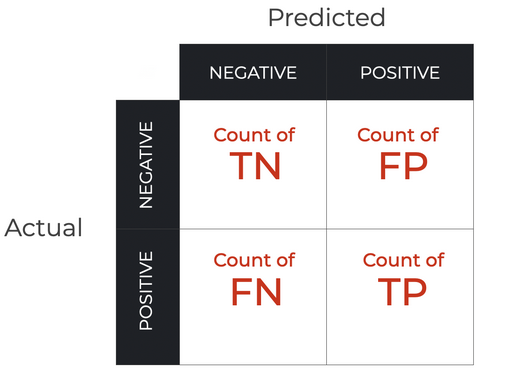

In [ ]:
dfK.case_id.sort_values()

In [ ]:
print(model.feature_importance_)

In [ ]:
pip install shap